In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
# Download Microsoft stock data
df = yf.download('MSFT', start='2020-01-01', end='2025-01-01')

df.head()

/tmp/ipykernel_2225/736669710.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('MSFT', start='2020-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2020-01-02,152.158401,152.262607,149.989047,150.415338,22622100
2020-01-03,150.263718,151.523654,149.733221,149.979534,21116200
2020-01-06,150.652145,150.718465,148.264897,148.804876,20813700
2020-01-07,149.278519,151.258412,149.032221,150.926859,21634100
2020-01-08,151.656342,152.328945,149.629079,150.557448,27746500


In [ ]:
#Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, MSFT)   1258 non-null   float64
 1   (High, MSFT)    1258 non-null   float64
 2   (Low, MSFT)     1258 non-null   float64
 3   (Open, MSFT)    1258 non-null   float64
 4   (Volume, MSFT)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [ ]:
#Basic Info
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,286.342937,289.107288,283.325570,286.270127,2.863777e+07
std,81.234206,81.506548,80.886439,81.302012,1.273673e+07
min,128.636353,133.528387,125.881635,130.146707,7.164500e+06
25%,227.027020,229.598693,223.850881,227.210018,2.049260e+07
50%,274.198425,277.606823,271.033031,274.711580,2.548105e+07
75%,330.945091,334.347327,328.430150,330.837490,3.290642e+07
max,461.322662,462.102132,458.264010,460.770111,9.701270e+07


In [ ]:
#Check Missing Values
df.isnull().sum()

,,0
Price,Ticker,
Close,MSFT,0
High,MSFT,0
Low,MSFT,0
Open,MSFT,0
Volume,MSFT,0


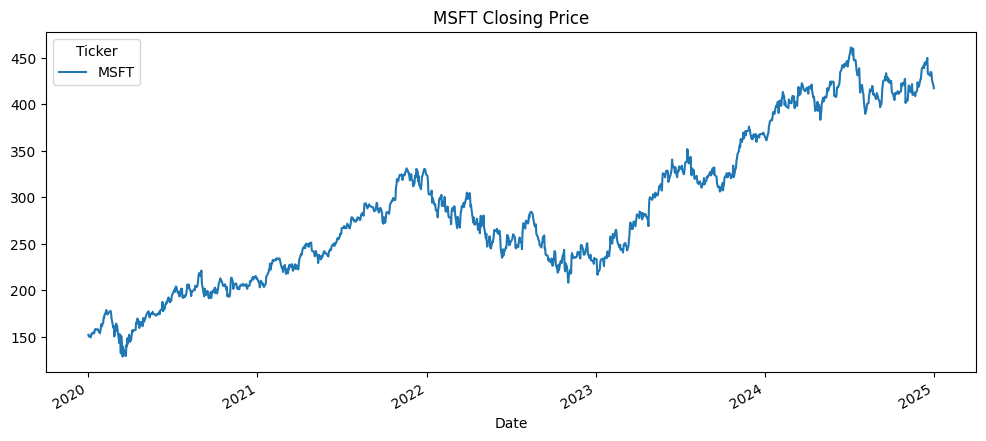

In [ ]:
#Plot Closing Price
df['Close'].plot(figsize=(12,5), title="MSFT Closing Price")
plt.show()

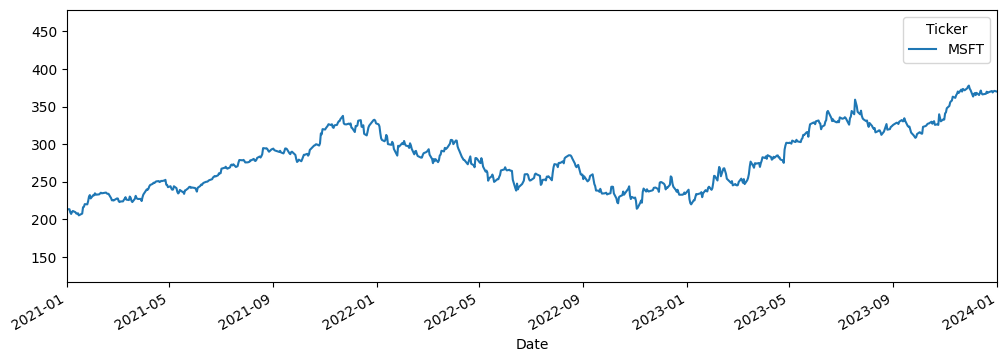

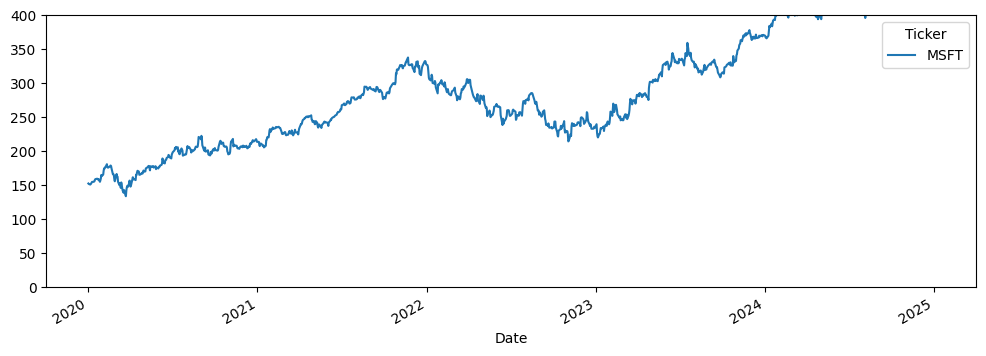

In [ ]:
#Plot High Price with Limits
df['High'].plot(xlim=['2021-01-01','2024-01-01'], figsize=(12,4))
plt.show()

df['High'].plot(ylim=[0,400], figsize=(12,4))
plt.show()

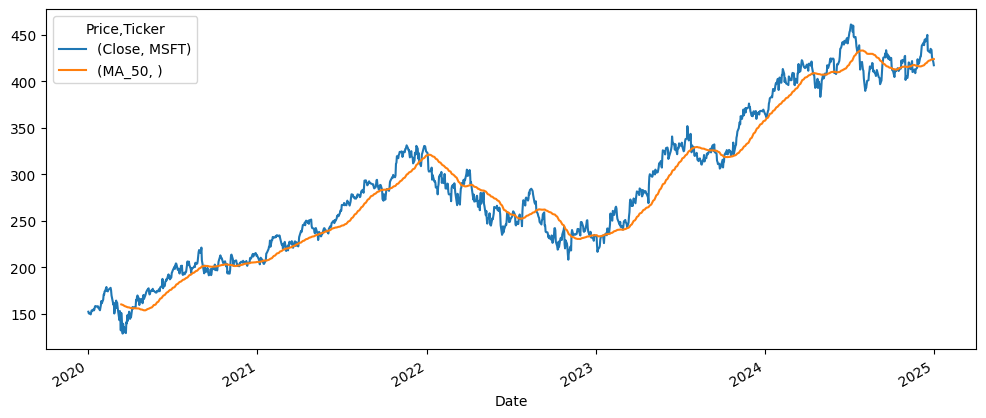

In [ ]:
#Moving Average
df['MA_50'] = df['Close'].rolling(window=50).mean()
df[['Close','MA_50']].plot(figsize=(12,5))
plt.show()

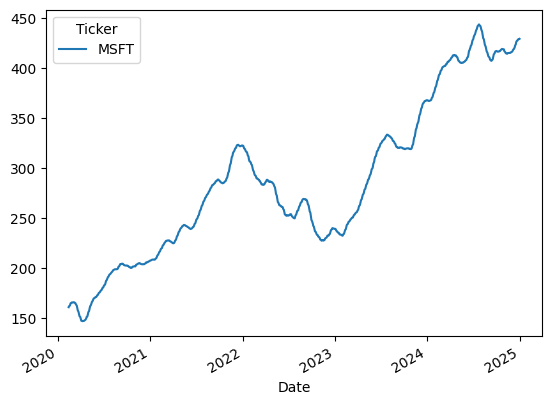

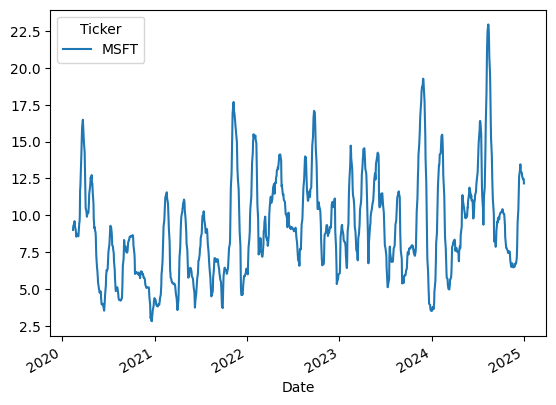

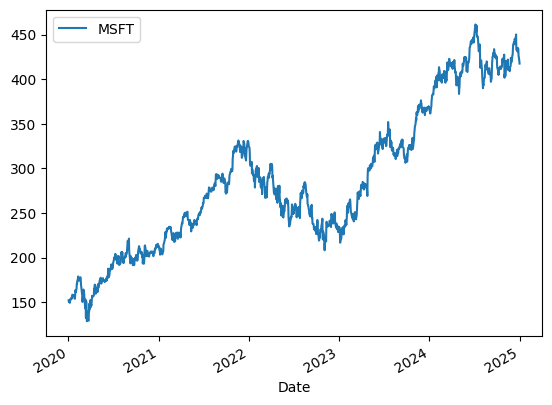

In [ ]:
#Rolling Statistics
df['Close'].rolling(window=30).mean().plot(label='Rolling Mean')
df['Close'].rolling(window=30).std().plot(label='Rolling Std')
df['Close'].plot(label='Original')
plt.legend()
plt.show()

/tmp/ipykernel_2225/3709034149.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M').mean()['Close'].plot(figsize=(12,5), title="Monthly Average Close")


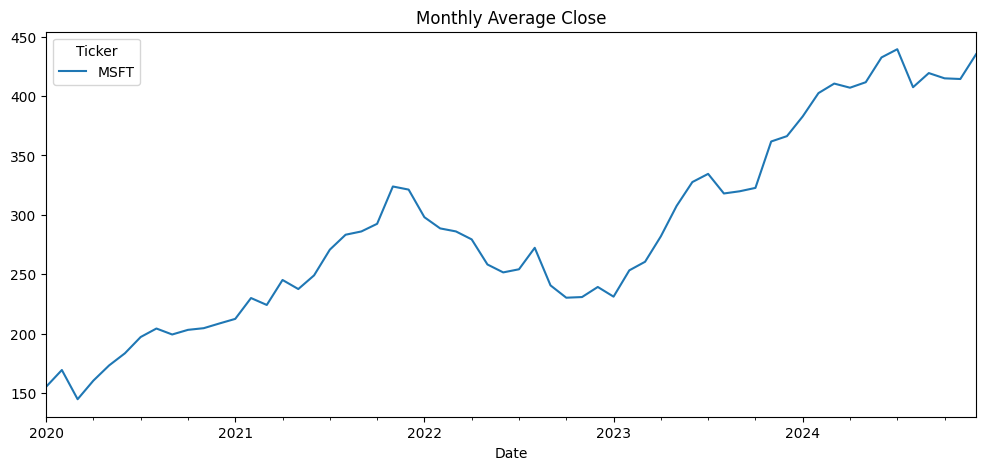

In [ ]:
#Resampling (Monthly Data)
df.resample('M').mean()['Close'].plot(figsize=(12,5), title="Monthly Average Close")
plt.show()

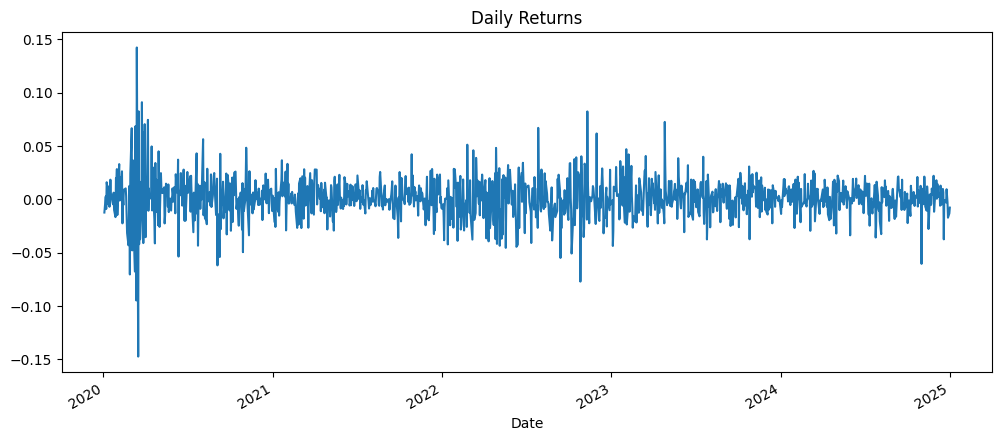

In [ ]:
#Daily Returns
df['Returns'] = df['Close'].pct_change()
df['Returns'].plot(figsize=(12,5), title="Daily Returns")
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

In [ ]:
#Check Stationarity (ADF Test)
result = adfuller(df['Close'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.0017709165046667
p-value: 0.7526178522044868


<Axes: title={'center': 'Differenced Data'}, xlabel='Date'>

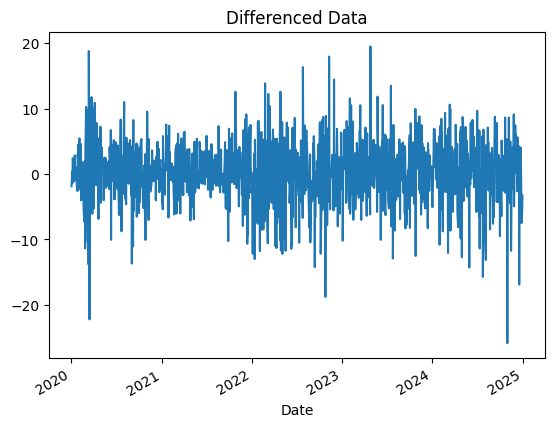

In [ ]:
#Apply Differencing
df['Close_diff'] = df['Close'].diff()
df['Close_diff'].dropna().plot(title="Differenced Data")

In [ ]:
#Build ARIMA Model
model = ARIMA(df['Close'], order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   MSFT   No. Observations:                 1258
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3749.499
Date:                Tue, 31 Mar 2026   AIC                           7504.999
Time:                        17:13:57   BIC                           7520.408
Sample:                             0   HQIC                          7510.790
                               - 1258                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2726      0.257      1.059      0.290      -0.232       0.777
ma.L1         -0.3573      0.253     -1.410      0.158      -0.854       0.139
sigma2        22.8261      0.690     33.085      0.0

In [ ]:
#Forecast Future Values
forecast = model_fit.forecast(steps=10)
print(forecast)

1258    417.992180
1259    418.137086
1260    418.176589
1261    418.187358
1262    418.190294
1263    418.191094
1264    418.191312
1265    418.191372
1266    418.191388
1267    418.191392
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
#Build SARIMA Model
model = SARIMAX(df['Close'],
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                               MSFT   No. Observations:                 1258
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -3742.250
Date:                            Tue, 31 Mar 2026   AIC                           7494.499
Time:                                    17:16:03   BIC                           7520.134
Sample:                                         0   HQIC                          7504.138
                                           - 1258                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3044      0.264      1.154      0.249      -0.213       0.822
ma.L1         -0.3895      0.258   

In [ ]:
#Forecast
forecast = model_fit.forecast(steps=10)
print(forecast)

1258    419.065484
1259    419.077011
1260    419.741005
1261    419.198079
1262    419.416813
1263    419.837025
1264    419.996723
1265    420.502303
1266    420.449474
1267    420.492456
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
